# Importing libraries

In [1]:
import re
import nltk
import pickle
import gensim
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from nltk import sent_tokenize
import gensim.downloader as api
from nltk.corpus import stopwords
from matplotlib import pyplot as plt
from nltk.stem import WordNetLemmatizer
from gensim.utils import simple_preprocess
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,f1_score,classification_report

import warnings
warnings.filterwarnings("ignore")

# Loading the dataset

In [2]:
issues_df = pd.read_csv('/content/sample1.csv')

In [3]:
issues_df.sample(5)

,issue_url,issue_label,issue_created_at,issue_author_association,repository_url,issue_title,issue_body
34859,https://api.github.com/repos/jelhan/create-git...,bug,2021-04-06T08:14:31Z,NONE,https://api.github.com/repos/jelhan/create-git...,Empty `include:` statement generated,An empty `include:` statement was generated [h...
33099,https://api.github.com/repos/artoh/kitupiikki/...,bug,2021-02-22T06:14:27Z,OWNER,https://api.github.com/repos/artoh/kitupiikki,Salasanasuojattu pdf Kirjattujen kansiossa aih...,"\r\n\r\n<!---\r\n@huboard:{""milestone_order"":3..."
9465,https://api.github.com/repos/PathOfBuildingCom...,bug,2021-01-13T15:50:07Z,NONE,https://api.github.com/repos/PathOfBuildingCom...,Error while trying to import a build,* What happened?\r\nError appeared\r\n* What w...
24401,https://api.github.com/repos/tachiyomiorg/tach...,bug,2021-05-26T12:28:03Z,NONE,https://api.github.com/repos/tachiyomiorg/tach...,[Bug] Luscious: Gifs is not playing in some ga...,\r\n## Device information\r\n- Tachiyomi versi...
34420,https://api.github.com/repos/EC-Earth/ece2cmor...,bug,2021-01-14T13:29:47Z,COLLABORATOR,https://api.github.com/repos/EC-Earth/ece2cmor3,Wrong horizontal interpolation in remapping fo...,While testing #682 we discovered that the rema...


# EDA

In [4]:
issues_df.shape

(72289, 7)

In [5]:
#Checking null values
issues_df.isnull().sum()

,0
issue_url,0
issue_label,0
issue_created_at,0
issue_author_association,0
repository_url,0
issue_title,0
issue_body,7148


# Data cleaning

In [6]:
#Drop null Values
issues_df.dropna(inplace=True)
issues_df.reset_index(drop=True,inplace=True)

In [7]:
#Considering only the useful columns from the dataframe
issues_df=issues_df[['issue_title','issue_body','issue_label']]
issues_df

,issue_title,issue_body,issue_label
0,__tileSrcRect is null in Entities.ldtk Sample ...,"In the Entities example, we there are some `__...",bug
1,Update the blog link in the SEF Site,**Describe the bug**\r\nUpdate the blog link i...,bug
2,🐛 Parser cannot properly distinguish between p...,Consider these two expressions:\r\n```\r\nf (g...,bug
3,"""Row added"" snackbar is not visible if the gri...",## Description \r\nWhen grid has no height an...,bug
4,[CRASH] _tcp_write_on_socket crashes when flu...,<!--\r\nThank you for reporting a crash in Ope...,bug
...,...,...,...
65136,[HELP] Volume Mount hostpath: Unable to mount ...,hi Team I am facing the below issue. Any solut...,question
65137,is form.progress valid for upload progress?,I thought form.progress would get fired every ...,question
65138,"RPi used for door contact sensors, warning in log",Thank you for the most excellent plug-in!! \r\...,question
65139,Tail latency of envoy proxy is bad if every re...,We have envoy running as the front door servic...,question


## Checking frequencies of each issue type

In [8]:
issue_label_counts_df = issues_df.issue_label.value_counts().reset_index()
issue_label_counts_df.columns = ['issue_label', 'count']

print(issue_label_counts_df)

   issue_label  count
0          bug  33745
1  enhancement  25295
2     question   6101


Text(0.5, 0, 'Frequency ')

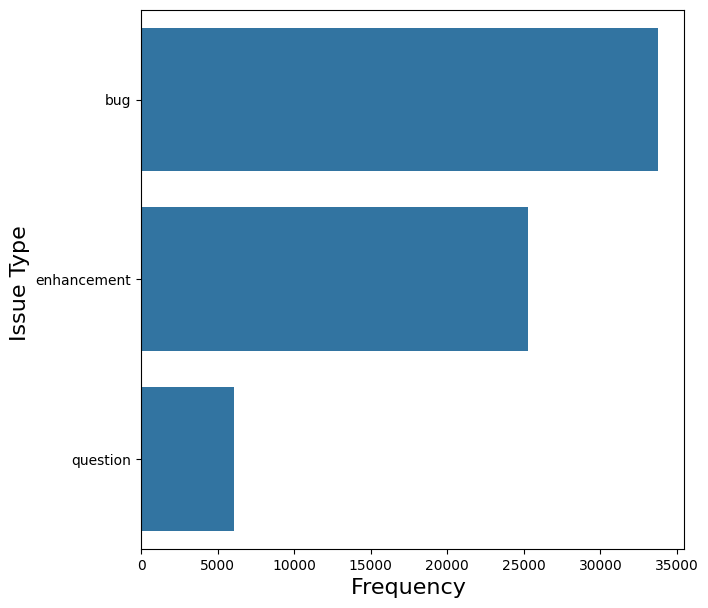

In [9]:
fig, ax = plt.subplots(figsize=(7, 7))

sns.barplot(data=issue_label_counts_df,
            x='count',
            y='issue_label',
            dodge=False,
            ax=ax)

plt.ylabel("Issue Type ",fontsize=16)
plt.xlabel("Frequency ",fontsize=16)

# Splitting the data into train and test set

In [10]:
# features (issue_title and issue_body) which will be used for training
X = issues_df.drop(['issue_label'], axis=1)
# target (issue_label) which needs to be predicted by the model
y = issues_df['issue_label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42,stratify=y)

In [11]:
print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

(52112, 2) (52112,)
(13029, 2) (13029,)


In [12]:
# Check class distribution in original dataset
unique, counts = np.unique(y, return_counts=True)
print("Original class distribution:", dict(zip(unique, counts)))

# Check class distribution in training set
unique, counts = np.unique(y_train, return_counts=True)
print("Training set class distribution:", dict(zip(unique, counts)))

# Check class distribution in testing set
unique, counts = np.unique(y_test, return_counts=True)
print("Testing set class distribution:", dict(zip(unique, counts)))

Original class distribution: {'bug': 33745, 'enhancement': 25295, 'question': 6101}
Training set class distribution: {'bug': 26995, 'enhancement': 20236, 'question': 4881}
Testing set class distribution: {'bug': 6750, 'enhancement': 5059, 'question': 1220}


# Data Preprocessing


In [13]:
nltk.download('punkt')
nltk.download('omw-1.4')
nltk.download('wordnet')
nltk.download('wordnet2022')
nltk.download('stopwords')
lemmatizer=WordNetLemmatizer()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package wordnet2022 to /root/nltk_data...
[nltk_data]   Package wordnet2022 is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Removing words like bug, enhancement, and question from the issue title

In [14]:
for index, row in X_train.iterrows():
  issue_title=re.sub(r'[\[\]]', '',row.issue_title.lower()) # Removes [ and ]

  if 'bug' in issue_title:
    X_train.loc[index,'issue_title']=re.sub(r'\bbug[s]?\b',"",issue_title)
  if 'enhancement' in issue_title:
    X_train.loc[index,'issue_title']=re.sub(r"enhancement","",issue_title)
  if 'question' in issue_title:
    X_train.loc[index,'issue_title']=re.sub(r"question","",issue_title)

In [15]:
#Check if the filtering worked or not
bug,enhancement,question=0,0,0
for index, row in X_train.iterrows():
  issue_title=row.issue_title.lower()
  if 'bug' in issue_title:
    bug+=1
  if 'enhancement' in issue_title:
    enhancement+=1
  if 'question' in issue_title:
    question+=1

print(f"{bug}, {enhancement}, {question}")

371, 2, 0


# Noise removal, Normalization, Tokenization, Removing Stop words and Lemmatization

In [19]:
sample=X_train.sample(10)
sample

,issue_title,issue_body
22257,Misalignment during circuit.draw(),"When drawing circuits of more than 10 qubits, ..."
45992,Can't remove an item from the cart,Customers are complaining that they can't remo...
24115,app.eachRepository does not support installati...,"According to README, users can _optionally pas..."
6492,Placement fails when a problem contains more t...,On the latest commit on the `FEATURE-0167-buff...
58410,Improve ResourceManager to handle various data...,Resource manager and everything related to res...
59580,IDToken acr value,actually we have the following IDToken\r\n\r\n...
29589,リスト更新後の処理が画面終了後に呼ばれるとクラッシュする場合がある,```\r\nFatal Exception: java.lang.NullPointerE...
2501,Tick labels can overlap when chart is panned,(split from #2 as a separate issue)\n\nWhen a ...
64085,اضافة خدمة الرسائل,![fawry](https://user-images.githubusercontent...
59382,Difference between BAcd16a16b and BAcd16b16a t...,"Hello,\r\n\r\nI was wondering what is the diff..."


In [20]:
def text_preprocessing(text):
  # Noise Removal: converting every non alphabetical or non english character to blank space
  preprocessed_text = re.sub('[^a-zA-Z?!]', ' ', text)
  # Normalization: making every character lowercase
  preprocessed_text = preprocessed_text.lower()
  # Tokenization: splitting words by space
  preprocessed_text=simple_preprocess(preprocessed_text)
  preprocessed_text = [lemmatizer.lemmatize(word) for word in preprocessed_text if not word in stopwords.words('english')]
  preprocessed_text = ' '.join(preprocessed_text)
  return preprocessed_text

In [21]:
#Testing the preprocessing
for index, row in sample.iterrows():
  issue_title=row.issue_title
  issue_body=row.issue_body

  sample.loc[index,'issue_title']=text_preprocessing(issue_title)
  sample.loc[index,'issue_body']=text_preprocessing(issue_body)

In [22]:
sample

,issue_title,issue_body
22257,misalignment circuit draw,drawing circuit qubits small misalignment due ...
45992,remove item cart,customer complaining remove item cart added cl...
24115,app eachrepository support installation id arg...,according readme user optionally pas installat...
6492,placement fails problem contains device,latest commit feature buffering softswitch bra...
58410,improve resourcemanager handle various data so...,resource manager everything related resource w...
59580,idtoken acr value,actually following idtoken sub dea aec dc dd f...
29589,,fatal exception java lang com suihan satena sc...
2501,tick label overlap chart panned,split separate issue graph dragged tick label ...
64085,,fawry http user image com eb eb caaa png
59382,difference bacd bacd tensor format,hello wondering difference weight tensor forma...


In [23]:
#Remove special characters, remove stopwords and lemmatize and store as corpus
corpus = [] #list of list of tokens
for index, row in tqdm(X_train.iterrows()):
  issue_title=row.issue_title
  issue_body=row.issue_body

  preprocessed_title=text_preprocessing(issue_title)
  preprocessed_body=text_preprocessing(issue_body)

  X_train.loc[index,'issue_title']=preprocessed_title
  X_train.loc[index,'issue_body']=preprocessed_body

  corpus.append((f'{preprocessed_title} {preprocessed_body}').split())

52112it [09:49, 88.43it/s]


# Save the preprocessed train set and the corpus

In [24]:
X_train.to_csv('/content/X_train_preprocessed.csv')
joblib.dump(corpus, "/content/corpus.pkl")

['/content/corpus.pkl']

### Load corpus

In [21]:
X_train = pd.read_csv('/content/X_train_preprocessed.csv')
corpus = joblib.load('/content/corpus.pkl')

In [26]:
X_train[:5]

,issue_title,issue_body
62741,disable seek bar video live stream,app using exoplayer lib app content provided u...
36803,airlock script,script manage airlock
6975,home page blog contains html tag,describe bug home page blog contains html tag ...
31506,azurerm cdn endpoint must match regex,community note please vote issue adding reacti...
55936,token based ably realtime authentication,provide capability authenticate user using abl...


In [25]:
corpus[:5]

[['disable',
  'seek',
  'bar',
  'video',
  'live',
  'stream',
  'app',
  'using',
  'exoplayer',
  'lib',
  'app',
  'content',
  'provided',
  'user',
  'played',
  'using',
  'internet',
  'content',
  'varied',
  'like',
  'may',
  'simple',
  'video',
  'live',
  'stream',
  'simple',
  'video',
  'need',
  'move',
  'video',
  'certain',
  'position',
  'help',
  'seek',
  'bar',
  'say',
  'need',
  'seek',
  'bar',
  'simple',
  'video',
  'example',
  'bug',
  'bunny',
  'http',
  'googleapis',
  'com',
  'gtv',
  'video',
  'bucket',
  'sample',
  'bigbuckbunny',
  'mp',
  'simple',
  'video',
  'seek',
  'bar',
  'example',
  'live',
  'stream',
  'video',
  'need',
  'seek',
  'bar',
  'move',
  'video',
  'certain',
  'position',
  'simple',
  'video',
  'main',
  'question',
  'disable',
  'seek',
  'bar',
  'user',
  'interact',
  'seek',
  'video',
  'live',
  'stream',
  'want',
  'something',
  'like',
  'want',
  'video',
  'live',
  'stream',
  'want',
  'exoplaye

# Training Word2Vec from scratch


In [27]:
import multiprocessing
cores = multiprocessing.cpu_count() # Count the number of cores in a computer
cores

2

## Why I seperate the training of the model in 3 steps:
I prefer to separate the training in 3 distinctive steps for clarity and monitoring.
1. `Word2Vec()`:
>In this first step, I set up the parameters of the model one-by-one. <br>I do not supply the parameter `sentences`, and therefore leave the model uninitialized, purposefully.
2. `.build_vocab()`:
>Here it builds the vocabulary from a sequence of sentences and thus initialized the model. <br>With the loggings, I can follow the progress and even more important, the effect of `min_count` and `sample` on the word corpus. I noticed that these two parameters, and in particular `sample`, have a great influence over the performance of a model. Displaying both allows for a more accurate and an easier management of their influence.
3. `.train()`:
>Finally, trains the model.<br>
The loggings here are mainly useful for monitoring, making sure that no threads are executed instantaneously.

## The parameters:

* `min_count` <font color='purple'>=</font> <font color='green'>int</font> - Ignores all words with total absolute frequency lower than this - (2, 100)


* `window` <font color='purple'>=</font> <font color='green'>int</font> - The maximum distance between the current and predicted word within a sentence. E.g. `window` words on the left and `window` words on the left of our target - (2, 10)


* `size` <font color='purple'>=</font> <font color='green'>int</font> - Dimensionality of the feature vectors. - (50, 300)


* `sample` <font color='purple'>=</font> <font color='green'>float</font> - The threshold for configuring which higher-frequency words are randomly downsampled. Highly influencial.  - (0, 1e-5)


* `alpha` <font color='purple'>=</font> <font color='green'>float</font> - The initial learning rate - (0.01, 0.05)


* `min_alpha` <font color='purple'>=</font> <font color='green'>float</font> - Learning rate will linearly drop to `min_alpha` as training progresses. To set it: alpha - (min_alpha * epochs) ~ 0.00


* `negative` <font color='purple'>=</font> <font color='green'>int</font> - If > 0, negative sampling will be used, the int for negative specifies how many "noise words" should be drown. If set to 0, no negative sampling is used. - (5, 20)


* `workers` <font color='purple'>=</font> <font color='green'>int</font> - Use these many worker threads to train the model (=faster training with multicore machines)

In [28]:
w2v_model = gensim.models.Word2Vec(min_count=5,
                                   window=5,
                                   vector_size=50,
                                   sample=6e-5,
                                   alpha=0.03,
                                   min_alpha=0.0001,
                                   negative=10,
                                   workers=cores-1)

# Building the Vocabulary Table:
Word2Vec requires us to build the vocabulary table (simply digesting all the words and filtering out the unique words, and doing some basic counts on them):



In [29]:
from time import time
t = time()
w2v_model.build_vocab(corpus, progress_per=5000)
print(f'Time to build vocab: {round((time() - t) / 60, 2)} mins')

Time to build vocab: 0.02 mins


In [30]:
w2v_model.corpus_count

52112

## Training of the model:
_Parameters of the training:_
* `total_examples` <font color='purple'>=</font> <font color='green'>int</font> - Count of sentences;
* `epochs` <font color='purple'>=</font> <font color='green'>int</font> - Number of iterations (epochs) over the corpus - [10, 20, 30]

In [31]:
t = time()

w2v_model.train(corpus, total_examples=w2v_model.corpus_count, epochs=15, report_delay=1)

print(f'Time to train the model: {round((time() - t) / 60, 2)} mins')

Time to train the model: 2.64 mins


In [32]:
#Save the model
w2v_model.save("/content/word2vec.model")

In [ ]:
#Load the model
w2v_model = gensim.models.Word2Vec.load("/content/word2vec.model")

In [33]:
# w2v_model.wv.index_to_key

# Check vocabulary size
w2v_model.corpus_count

# w2v_model.epochs

52112

In [34]:
w2v_model.wv['error']

array([ 7.9653978e-01, -4.0111515e-01,  9.4479477e-01, -4.7553313e-01,
       -1.1586547e+00, -6.9738716e-01, -3.4496459e-01, -2.1933978e+00,
       -9.8097175e-01, -2.2589670e-01,  1.3797898e+00,  1.0534940e+00,
       -1.7556645e+00, -1.4089329e+00,  1.1365896e+00,  4.3548024e-01,
        7.7725339e-01,  1.2219249e+00,  3.1855416e-01, -8.1125796e-02,
        2.8133213e-03, -5.4667842e-02, -6.9753450e-01, -1.1446265e+00,
       -4.1821316e-02,  6.9584924e-01, -1.4805398e+00, -8.2841837e-01,
        2.1682448e+00,  1.7963452e+00,  1.3447455e+00, -1.0049208e+00,
       -1.1062880e+00,  1.9053391e+00, -6.2270892e-01, -8.5329562e-01,
       -1.2130336e+00, -3.4000258e+00, -4.8557320e-01, -1.9156835e+00,
        1.2260134e-01,  7.9657733e-02,  2.5080490e-01, -2.2397748e-01,
        1.2314649e+00,  1.3330058e+00,  3.8587758e-01,  1.0780960e+00,
        9.4420291e-02, -3.5141221e-01], dtype=float32)

In [35]:
w2v_model.wv['error'].shape

(50,)

In [36]:
w2v_model.wv.similar_by_word('error')

[('failed', 0.7971680760383606),
 ('occurred', 0.7794893980026245),
 ('exception', 0.7352188229560852),
 ('fatal', 0.7131451368331909),
 ('unexpected', 0.7103314995765686),
 ('throw', 0.7031994462013245),
 ('message', 0.6971740126609802),
 ('got', 0.6903461813926697),
 ('failure', 0.6747102737426758),
 ('aborted', 0.6740594506263733)]

In [37]:
w2v_model.wv.similarity('bug', 'problem')

0.72980434

# Average the vectors of each word in a sentence to a single vector


In [ ]:
# To average the vectors of each word in a sentence to a single vector
# def avg_word2vec(doc):
#     # remove out-of-vocabulary words
#     return np.mean([w2v_model.wv[word] for word in doc if word in w2v_model.wv.index_to_key],axis=0)

In [38]:
def avg_word2vec(doc):
    valid_words = [w2v_model.wv[word] for word in doc if word in w2v_model.wv.index_to_key]
    if not valid_words:
        return np.zeros(50)  # Return zero vector if no words are found
    return np.mean(valid_words, axis=0)

### Applying AvgerageWord2Vec for the entire sentences


In [39]:
# Compute separate vectors for title and body
title_vectors,body_vectors = [],[]

for _, row in tqdm(X_train.iterrows()):
  title_vectors.append(avg_word2vec(row.issue_title.split()))
  body_vectors.append(avg_word2vec(row.issue_body.split()))

# Convert to NumPy arrays
title_vectors = np.array(title_vectors)
body_vectors = np.array(body_vectors)

# Concatenate title and body vectors to form final feature vector
X_train_feature_vec = np.hstack((title_vectors, body_vectors))  # Shape (num_samples, 100) if each vector is size 50

52112it [09:55, 87.48it/s] 


In [40]:
#Save feature vectors
joblib.dump(X_train_feature_vec, "/content/X_train_feature_vec.pkl")

['/content/X_train_feature_vec.pkl']

In [ ]:
X_train_feature_vec = joblib.load("/content/X_train_feature_vec.pkl")

In [51]:
X_train_feature_vec[:5]

array([[ 7.55914211e-01, -1.85753500e+00, -6.05212748e-01,
         5.87512970e-01, -9.40567970e-01, -7.22862959e-01,
        -1.62218630e+00,  5.82784653e-01, -8.06226075e-01,
         1.17714942e+00,  1.26464516e-01, -1.65879190e-01,
        -6.48796260e-01, -7.23184586e-01, -7.16216266e-01,
         1.09581053e-01, -8.90761912e-01, -1.76942742e+00,
         1.23404634e+00, -3.98983985e-01,  1.09088123e-02,
        -2.15800717e-01, -2.41553211e+00,  5.83031356e-01,
         8.06966782e-01,  1.62414360e+00, -1.46525070e-01,
        -2.56169170e-01,  3.08658481e-01,  2.94356614e-01,
        -7.63785839e-01,  5.10865867e-01, -6.80355072e-01,
        -2.46292558e-02, -2.10508630e-01,  7.48314559e-01,
        -1.73563254e+00, -9.92393494e-01, -2.65485436e-01,
         6.21438809e-02,  4.97476645e-02, -9.07340527e-01,
         5.98537266e-01, -9.30381596e-01, -1.00134516e+00,
        -1.51642907e+00, -1.21630871e+00,  5.53334653e-01,
        -3.47250909e-01, -3.16118747e-01,  3.97627532e-0

In [41]:
X_train_feature_vec.shape

(52112, 100)

In [42]:
X_train.shape

(52112, 2)

In [43]:
#vector for the first instance
X_train_feature_vec[0]

array([ 7.55914211e-01, -1.85753500e+00, -6.05212748e-01,  5.87512970e-01,
       -9.40567970e-01, -7.22862959e-01, -1.62218630e+00,  5.82784653e-01,
       -8.06226075e-01,  1.17714942e+00,  1.26464516e-01, -1.65879190e-01,
       -6.48796260e-01, -7.23184586e-01, -7.16216266e-01,  1.09581053e-01,
       -8.90761912e-01, -1.76942742e+00,  1.23404634e+00, -3.98983985e-01,
        1.09088123e-02, -2.15800717e-01, -2.41553211e+00,  5.83031356e-01,
        8.06966782e-01,  1.62414360e+00, -1.46525070e-01, -2.56169170e-01,
        3.08658481e-01,  2.94356614e-01, -7.63785839e-01,  5.10865867e-01,
       -6.80355072e-01, -2.46292558e-02, -2.10508630e-01,  7.48314559e-01,
       -1.73563254e+00, -9.92393494e-01, -2.65485436e-01,  6.21438809e-02,
        4.97476645e-02, -9.07340527e-01,  5.98537266e-01, -9.30381596e-01,
       -1.00134516e+00, -1.51642907e+00, -1.21630871e+00,  5.53334653e-01,
       -3.47250909e-01, -3.16118747e-01,  3.97627532e-01, -1.20654058e+00,
       -2.00097188e-01,  

In [44]:
X_train_feature_vec[0].shape

(100,)

In [49]:
# We have to make each vector as one row as the features for the instance
X_train_feature_vec[0].reshape(1,-1).shape

(1, 100)

# Final dependent and independent features

In [52]:
#make the feature space for all the datapoints
vec_list=[]
for index,vec in enumerate(X_train_feature_vec):
  #Only consider the vectors with shape 100
  if vec.shape==(100,):
    vec_list.append(vec)

In [55]:
# We have to make each vector as one row as the features for the instance
df=pd.DataFrame(vec_list)

In [57]:
df

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.755914,-1.857535,-0.605213,0.587513,-0.940568,-0.722863,-1.622186,0.582785,-0.806226,1.177149,...,0.334376,-0.336210,0.351516,-1.150992,-0.688223,-0.870086,-0.967719,0.000976,-0.595792,0.020069
1,-0.063029,-1.226458,-0.193379,0.273127,0.019813,-0.594181,-0.851220,-0.328388,-0.443701,-0.064917,...,-0.829086,-0.884076,0.212373,0.646297,-0.080855,0.288439,0.277447,0.196296,1.401300,-0.261703
2,-0.650449,-0.380579,0.691659,-0.155790,0.936337,0.613907,-0.779647,-0.424669,-2.116510,0.923724,...,1.263795,-1.081176,0.297483,-0.947483,-0.589496,-0.147973,-1.132479,0.019656,-0.425711,-0.296004
3,0.606637,0.340122,1.600321,-0.160844,1.365801,-0.580227,-0.007644,-1.019922,-2.592788,0.834386,...,-0.000627,0.294604,0.282789,-0.791523,-0.710109,0.147177,-0.434085,0.336890,0.070157,-0.234588
4,-0.193263,0.097375,0.915390,-0.367721,0.254093,0.376177,0.686615,-0.700929,-2.030279,0.292725,...,-0.414894,-0.072928,0.246506,-1.441299,-0.297857,-0.061528,-0.964989,-0.591544,0.286807,0.104664
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52107,-0.180774,-0.749740,0.161454,0.533254,-0.273856,0.567772,-0.968802,0.893413,-2.150618,0.842458,...,-0.062893,-0.264953,0.248972,-1.020392,-0.487755,0.033266,-0.902972,0.046491,-0.398788,-0.309790
52108,-0.129052,-0.766777,-0.538518,0.078350,1.221842,0.230848,-0.880764,0.389750,-0.839211,-0.574893,...,0.250197,0.389474,0.107504,-0.370448,0.935842,-0.367489,-0.363219,0.117733,-0.801223,-0.828517
52109,-0.058226,-0.050044,-0.944369,0.267288,-0.288871,0.235517,-1.601710,-0.045506,-0.363265,0.128893,...,-0.388625,0.098045,-0.115251,-0.775152,0.208626,-0.434550,-0.792474,-0.799329,-0.708799,-0.335505
52110,-0.369615,-0.601055,-0.204221,0.236471,-0.289007,0.758919,-0.628139,-0.659288,-2.028983,0.447063,...,0.650142,-0.179013,0.137357,-1.330526,-0.421583,-0.348565,-0.875199,-0.626118,-0.376132,-0.021877


In [58]:
#save the features dataframe
df.to_csv('/content/X_train_features.csv', index=False)

In [ ]:
#load the features dataframe
df=pd.read_csv('/content/X_train_features.csv')

In [59]:
df.shape

(52112, 100)

In [60]:
#Independent features
X_train_features=df

In [66]:
#dependent feature (target)
y_train=np.array(y_train)
y_train

array(['question', 'enhancement', 'bug', ..., 'enhancement', 'bug', 'bug'],
      dtype=object)

In [67]:
#encoding the labels
from sklearn.preprocessing import LabelEncoder

# Creating a instance of label Encoder.
le = LabelEncoder()
y_train = le.fit_transform(y_train)

In [69]:
y_train
#0: bug, 1:enhancement, 2: question

array([2, 1, 0, ..., 1, 0, 0])

In [70]:
y_train.shape

(52112,)

# Creating a Random Forest Classifier

In [137]:
classifier=RandomForestClassifier(class_weight="balanced",random_state=40)
# classifier = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)

In [138]:
#Training the RFclassifier
classifier.fit(X_train_features,y_train)

RandomForestClassifier(class_weight='balanced', random_state=40)

In [145]:
# save
joblib.dump(classifier, "/content/rf_classifier.joblib")

# load
# classifier = joblib.load("/content/rf_classifier.joblib")

['/content/rf_classifier.joblib']

In [127]:
# Preprocess the test set
for index, row in tqdm(X_test.iterrows()):
  issue_title=row.issue_title
  issue_body=row.issue_body

  preprocessed_title=text_preprocessing(issue_title)
  preprocessed_body=text_preprocessing(issue_body)

  X_test.loc[index,'issue_title']=preprocessed_title
  X_test.loc[index,'issue_body']=preprocessed_body

# Compute separate vectors for title and body
title_vectors,body_vectors = [],[]

for _, row in tqdm(X_test.iterrows()):
  title_vectors.append(avg_word2vec(row.issue_title.split()))
  body_vectors.append(avg_word2vec(row.issue_body.split()))

# Convert to NumPy arrays
title_vectors = np.array(title_vectors)
body_vectors = np.array(body_vectors)

# Concatenate title and body vectors to form final feature vector
X_test_feature_vec = np.hstack((title_vectors, body_vectors))

test_vec_list=[]
for index,vec in enumerate(X_test_feature_vec):
  #Only consider the vectors with shape 100
  if vec.shape==(100,):
    test_vec_list.append(vec)

X_test_features=pd.DataFrame(test_vec_list)

13029it [02:00, 108.04it/s]
13029it [03:15, 66.68it/s]


In [77]:
#save the testfeatures dataframe
X_test_features.to_csv('/content/X_test_features.csv', index=False)

In [78]:
#load the test features dataframe
X_test_features=pd.read_csv('/content/X_test_features.csv')

In [128]:
#encoding the test labels
y_test=np.array(y_test)
# Creating a instance of label Encoder.
le = LabelEncoder()
y_test = le.fit_transform(y_test)

In [139]:
#predictions for the test data
y_pred=classifier.predict(X_test_features)

In [121]:
y_pred.shape

(13029,)

In [143]:
#predicting one test value
pred=classifier.predict(X_test_features[1:2])
pred

array([1])

In [144]:
y_test[1]

1

# Model evaluation

In [142]:
# print(accuracy_score(y_true=y_test,y_pred=y_pred))
print(classification_report(y_true=y_test,y_pred=y_pred,target_names=['Bug','Enhancement','Question']))
print(f"Macro f1 score: {f1_score(y_true=y_test,y_pred=y_pred,average='macro'):.2f}")

              precision    recall  f1-score   support

         Bug       0.73      0.87      0.80      6750
 Enhancement       0.73      0.71      0.72      5059
    Question       0.51      0.02      0.03      1220

    accuracy                           0.73     13029
   macro avg       0.66      0.53      0.52     13029
weighted avg       0.71      0.73      0.70     13029

Macro f1 score: 0.52


# Making predictions

In [111]:
def make_prediction (issue_title,issue_body):
  preprocessed_title=text_preprocessing(issue_title)
  preprocessed_body=text_preprocessing(issue_body)

  # Compute separate vectors for title and body
  title_vectors=[avg_word2vec(preprocessed_title.split())]
  body_vectors=[avg_word2vec(preprocessed_body.split())]

  # Convert to NumPy arrays
  title_vectors = np.array(title_vectors)
  body_vectors = np.array(body_vectors)

  # Concatenate title and body vectors to form final feature vector
  feature_vec = np.hstack((title_vectors, body_vectors))

  # the input to the model should be of the shape (1,100)
  feature_vec.reshape(1,-1)

  return classifier.predict_proba(feature_vec).tolist()[0]

In [146]:
issue_title='OTLPMetricExporter ignores preferred_aggregation'
issue_body='''**Describe your environment** Describe any aspect of your environment relevant to the problem, including your Python version, [platform](https://docs.python.org/3/library/platform.html), version numbers of installed dependencies, information about your cloud hosting provider, etc. If you're reporting a problem with a specific version of a library in this repo, please check whether the problem has been fixed on main.

Python == 3.11.6
opentelemetry-exporter-otlp == 1.20.0
opentelemetry-sdk == 1.20.0

**Steps to reproduce**
Describe exactly how to reproduce the error. Include a code sample if applicable.

Instantiating metric exporter:

```python
metric_reader = PeriodicExportingMetricReader(
    OTLPMetricExporter(
        endpoint=<>,
        preferred_aggregation={
            Histogram: ExponentialBucketHistogramAggregation()
        },
    ),
)
meter_provider = MeterProvider(
    resource=resource, metric_readers=[metric_reader]
)
metrics.set_meter_provider(meter_provider)
```

**What is the expected behavior?**
What did you expect to see?

Preferred aggregation set on the exporter and reader for Histograms to be ExponentialBucketHistogramAggregation.

**What is the actual behavior?**
What did you see instead?

Preferred aggregation set on the exporter and reader for Histograms is default (ExplicitBucketHistogramAggregation)

**Additional context**
Add any other context about the problem here.

Looking at the code in OTLPMetricExporter.**init**, it looks like the preferred_aggregation arg is not used at all.
'''
bug,enhancement,question=make_prediction(issue_title,issue_body)
print(f'Probability of bug: {bug:.2f} \nProbability of enhancement: {enhancement:.2f}\nProbability of question: {question:.2f}')

Probability of bug: 0.52 
Probability of enhancement: 0.38
Probability of question: 0.10
